# Compute the global time series

In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())

Loading packages...


/home/b/b384080/.conda/envs/eekenv/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


## 0) define functions

In [2]:
def calc_vertical_stat(da, thickness_weights, stat, mask=None, dims=None):
    if stat == 'mean':
        da_stat = SpaceOperator.calc_vertical_mean(da, thickness_weights, mask=mask, dims=dims)
    elif stat == 'integral':
        da_stat = SpaceOperator.calc_vertical_integral(da, thickness_weights, mask=mask, dims=dims)
    return da_stat

def calc_horizontal_stat(da, area_weights, stat, mask=None, dims=None,grid_cell_fractions=None):
    if stat == 'mean':
        da_stat = SpaceOperator.calc_spatial_mean(da, area_weights, mask=mask, dims=dims, grid_cell_fractions=grid_cell_fractions)
    elif stat == 'integral':
        da_stat = SpaceOperator.calc_spatial_integral(da, area_weights, mask=mask, dims=dims, grid_cell_fractions=grid_cell_fractions)
    return da_stat

def get_stat(varia,model):

    # default settings
    if varia in ['tas','tos','chlos','co2s']:
        stat = 'mean'
    elif varia in ['fgco2','intpp','nbp','npp','cLand','cSoil','cVeg','cCwd','cLitter','dissic','fco2antt','intdic','epc100']:
        stat = 'integral'
    elif varia in ['co2mass']:
        stat = None

    # overwrite some choices
    if model == 'GISSE2.1-G-CC2':
        if varia == 'co2mass':
            stat = 'integral'
    
    return stat

def get_vert_stat(varia,default=True):
    if default == True:
        if varia in ['dissic']:
            vert_stat = 'integral'
        else:
            vert_stat = None
    else:
        vert_stat = None
    return vert_stat

## 1) get the varias, models and runs over which to do computation

In [3]:
#stat = 'integral'#'mean'
freq_input = 'monthly'#, 'yearly', 'daily'] #freq_output = 'monthly'#, 'yearly', 'daily', 'climatology', None]
varias = ['fgco2']#['npp','cSoil','cLand','cVeg']#['fgco2','tas']#['epc100']#['fgco2','intpp','npp','cLand']#['co2s']#['intpp','chlos','epc100']#['cLand','cVeg','cSoil','npp','co2mass','tas','tos','fgco2','nbp','fco2antt','intpp','npp','cLand','cVeg','cSoil','intdic']#['npp','cLand','fgco2','nbp','fco2antt']#'fco2antt']#['tas','nbp','fgco2','fco2antt','co2mass','tos','npp']#]#['intpp','npp','tos'] # ['fgco2','nbp','cLand','dissic','cSoil','cVeg','cLitter','cCwd']#  # 'tas',                ,'co2mass']#['fgco2']#['nbp']#['nbp','cLand'] #['nbp']#['nbp']#['fco2antt']#['cLand','cSoil','cVeg','cLitter','cCwd']#['cLitter']#'cCwd',#['cLand']#['cSoil','cVeg']#['cLitter']#['cCwd']#['cSoil','cVeg']#'cLand',#['tas','nbp','npp','tos','fgco2','intpp']
models = ['CESM2']#['IPSL-CM6-ESMCO2']#['NorESM2-LM']#['IPSL-CM6-ESMCO2','NorESM2-LM','GFDL-ESM2M']#['MIROC-ES2L'] ['IPSL-CM6-ESMCO2']#['EC-Earth3-ESM-1']#['UKESM1-2']#['GISSE2.1-G-CC2']#['IPSL-CM6-ESMCO2']#['IPSL-CM6-ESMCO2']#[]#['GISSE2.1-G-CC2']#['EC-Earth3-ESM-1']#,'UKESM1-2']#['NorESM2-LM']#['GFDL-ESM2M']#['IPSL-CM6-ESMCO2']#['UKESM1-2']#['IPSL-CM6-ESMCO2','NorESM2-LM','GFDL-ESM2M'] # ,
runs = pruns.get_run_list('tipmip_tier1')#[:-1]#[:1]#[-1:]#[:1]#[:1]#[1:]#[-1:] #

outroot = './../01_postprocessed_data/global_time_series'

## 2) loop over models and runs to do the computation, plotting and saving

In [4]:
from dask.distributed import Client
client = Client()

2026-05-13 10:49:46,437 - distributed.utils_perf - WARNING - full garbage collections took 10% CPU time recently (threshold: 10%)
2026-05-13 10:50:10,340 - distributed.utils_perf - WARNING - full garbage collections took 10% CPU time recently (threshold: 10%)
2026-05-13 10:57:08,119 - distributed.utils_perf - WARNING - full garbage collections took 10% CPU time recently (threshold: 10%)
2026-05-13 11:00:49,926 - distributed.utils_perf - WARNING - full garbage collections took 10% CPU time recently (threshold: 10%)
2026-05-13 11:00:56,601 - distributed.utils_perf - WARNING - full garbage collections took 10% CPU time recently (threshold: 10%)


In [5]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 40,Total memory: 80.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37067,Workers: 8
Dashboard: http://127.0.0.1:8787/status,Total threads: 40
Started: Just now,Total memory: 80.00 GiB
Comm: tcp://127.0.0.1:40877,Total threads: 5
Dashboard: http://127.0.0.1:35191/status,Memory: 10.00 GiB
Nanny: tcp://127.0.0.1:43985,


fgco2
FG_CO2
Processing data for FG_CO2, CESM2, esm-piControl...
['/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-piControl.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-piControl.001.pop.h.FG_CO2.000101-001012.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-piControl.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-piControl.001.pop.h.FG_CO2.001101-002012.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-piControl.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-piControl.001.pop.h.FG_CO2.002101-003012.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-piControl.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-piControl.001.pop.h.FG_CO2.003101-004012.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-piControl.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-piControl.001.pop.h.FG_CO2.004101-005012.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-piControl.001/ocn/proc/tseries/month_1/b.

/home/b/b384080/TIPMIP_carbon_cycle/01_postprocessing/../00_modules/./misc_functions.py:26: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(files,use_cftime=True, data_vars="minimal", coords="minimal", compat="override")
/home/b/b384080/TIPMIP_carbon_cycle/01_postprocessing/../00_modules/./misc_functions.py:26: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(files,use_cftime=True, data_vars="minimal", coords="minimal", compat="override")
/home/b/b3

<xarray.DataArray 'FG_CO2' (time: 8568, nlat: 384, nlon: 320)> Size: 4GB
dask.array<concatenate, shape=(8568, 384, 320), dtype=float32, chunksize=(1, 384, 320), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 69kB 0001-02-01 00:00:00 ... 0715-01-01 00:00:00
    ULONG    (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    ULAT     (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    TLONG    (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    TLAT     (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
Dimensions without coordinates: nlat, nlon
Attributes:
    long_name:     DIC Surface Gas Flux
    units:         mmol/m^3 cm/s
    grid_loc:      2110
    cell_methods:  time: mean
... loading 8568 data points in time.
... getting area weights.
getting land area fraction if necessary
... compute horizontal statistic
FG_CO2
fgco2
... saving under ./../01_postproc

/home/b/b384080/TIPMIP_carbon_cycle/01_postprocessing/../00_modules/./misc_functions.py:26: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(files,use_cftime=True, data_vars="minimal", coords="minimal", compat="override")
/home/b/b384080/TIPMIP_carbon_cycle/01_postprocessing/../00_modules/./misc_functions.py:26: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(files,use_cftime=True, data_vars="minimal", coords="minimal", compat="override")
/home/b/b3

<xarray.DataArray 'FG_CO2' (time: 3000, nlat: 384, nlon: 320)> Size: 1GB
dask.array<concatenate, shape=(3000, 384, 320), dtype=float32, chunksize=(1, 384, 320), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 24kB 0001-02-01 00:00:00 ... 0251-01-01 00:00:00
    ULONG    (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    ULAT     (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    TLONG    (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    TLAT     (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
Dimensions without coordinates: nlat, nlon
Attributes:
    long_name:     DIC Surface Gas Flux
    units:         mmol/m^3 cm/s
    grid_loc:      2110
    cell_methods:  time: mean
... loading 3000 data points in time.
... getting area weights.
getting land area fraction if necessary
... compute horizontal statistic
FG_CO2
fgco2
... saving under ./../01_postproc

...

<xarray.DataArray 'FG_CO2' (time: 1980, nlat: 384, nlon: 320)> Size: 973MB
dask.array<concatenate, shape=(1980, 384, 320), dtype=float32, chunksize=(1, 384, 320), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 16kB 0166-02-01 00:00:00 ... 0331-01-01 00:00:00
    ULONG    (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    ULAT     (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    TLONG    (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    TLAT     (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
Dimensions without coordinates: nlat, nlon
Attributes:
    long_name:     DIC Surface Gas Flux
    units:         mmol/m^3 cm/s
    grid_loc:      2110
    cell_methods:  time: mean
... loading 1980 data points in time.
... getting area weights.
getting land area fraction if necessary
... compute horizontal statistic
FG_CO2
fgco2
... saving under ./../01_postpr

/home/b/b384080/TIPMIP_carbon_cycle/01_postprocessing/../00_modules/./misc_functions.py:26: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(files,use_cftime=True, data_vars="minimal", coords="minimal", compat="override")
/home/b/b384080/TIPMIP_carbon_cycle/01_postprocessing/../00_modules/./misc_functions.py:26: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(files,use_cftime=True, data_vars="minimal", coords="minimal", compat="override")
/home/b/b3

<xarray.DataArray 'FG_CO2' (time: 4080, nlat: 384, nlon: 320)> Size: 2GB
dask.array<concatenate, shape=(4080, 384, 320), dtype=float32, chunksize=(1, 384, 320), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 33kB 0281-02-01 00:00:00 ... 0621-01-01 00:00:00
    ULONG    (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    ULAT     (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    TLONG    (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    TLAT     (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
Dimensions without coordinates: nlat, nlon
Attributes:
    long_name:     DIC Surface Gas Flux
    units:         mmol/m^3 cm/s
    grid_loc:      2110
    cell_methods:  time: mean
... loading 4080 data points in time.
... getting area weights.
getting land area fraction if necessary
... compute horizontal statistic
FG_CO2
fgco2
... saving under ./../01_postproc

/home/b/b384080/TIPMIP_carbon_cycle/01_postprocessing/../00_modules/./misc_functions.py:26: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(files,use_cftime=True, data_vars="minimal", coords="minimal", compat="override")
/home/b/b384080/TIPMIP_carbon_cycle/01_postprocessing/../00_modules/./misc_functions.py:26: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds = xr.open_mfdataset(files,use_cftime=True, data_vars="minimal", coords="minimal", compat="override")
/home/b/b3

<xarray.DataArray 'FG_CO2' (time: 3648, nlat: 384, nlon: 320)> Size: 2GB
dask.array<concatenate, shape=(3648, 384, 320), dtype=float32, chunksize=(1, 384, 320), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 29kB 0406-02-01 00:00:00 ... 0710-01-01 00:00:00
    ULONG    (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    ULAT     (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    TLONG    (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    TLAT     (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
Dimensions without coordinates: nlat, nlon
Attributes:
    long_name:     DIC Surface Gas Flux
    units:         mmol/m^3 cm/s
    grid_loc:      2110
    cell_methods:  time: mean
... loading 3648 data points in time.
... getting area weights.
getting land area fraction if necessary
... compute horizontal statistic
FG_CO2
fgco2
... saving under ./../01_postproc

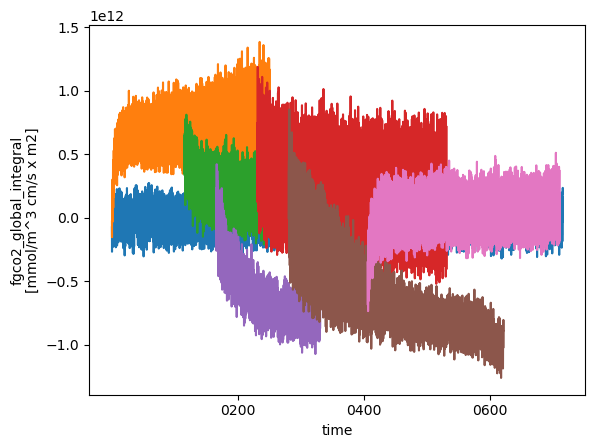

In [4]:
for varia in varias:
    for model in models:
        mgrab = MODELgrabber.get_grabber(model)
        stat = get_stat(varia,model)
        vert_stat = get_vert_stat(varia,default=True)
        member = mgrab.get_member()

        global_stats = dict()
        for run in runs:

            if model == 'CESM2':
                print(varia)
                varia = mgrab.varia_mapper_cmor_to_model(varia)
                print(varia)
    
            domain = mgrab.get_domain(varia,freq_input)
        
            print(f'Processing data for {varia}, {model}, {run}...')
            
            # first get the dataset
            da = mgrab.get_data(varia,run,freq_input=freq_input,verbose_level=1)
            print(f'... loading {da.time.size} data points in time.')
        
            # =====================================================
            # OPTIONAL VERTICAL STAT
            # =====================================================
            if vert_stat is not None:
                da = da.chunk({"time": 12,"lev": -1})#,"i": -1,"j": -1})
                #print(da)
                
                print('... get thickness weights')

                if model == 'NorESM2-LM':
                    thickness_weights = mgrab.get_thickness(
                        'thkcello',freq_input)
                    thickness_weights = thickness_weights.chunk({"lev": -1})#,"i": -1,"j": -1})
                else:
                    thickness_weights = mgrab.get_data(
                        'thkcello', run, freq_input=freq_input, verbose_level=0)
                    thickness_weights = thickness_weights.chunk({"time": 12,"lev": -1})#,"i": -1,"j": -1})
                #print(thickness_weights)
                
                print('... compute vertical statistic')
                da_for_horiz = calc_vertical_stat(
                    da,
                    thickness_weights,
                    vert_stat,
                    mask=None,
                    dims=None
                )
                da_for_horiz.name = f"{varia}_vertical_{vert_stat}"
                da_for_horiz = da_for_horiz.persist()
            else:
                da_for_horiz = da

            # =====================================================
            # HORIZONTAL STAT (on correct input)
            # =====================================================
            
            if stat is not None:
                # get the area_weights
                print(f'... getting area weights.')
                area_weights = mgrab.get_area(varia,freq_input)
                #area_weights.plot();plt.show()
                #print(area_weights.lat)
                
                # which region do i want to cover
                #print(f'... getting a regional mask.') 
                
                #if varia in ['nbp','cLand']:
                print('getting land area fraction if necessary')
                grid_cell_fractions = mgrab.get_area_fraction(varia)
                #grid_cell_fractions.plot();plt.show()
                #print(grid_cell_fractions.lat)
                #else:
                #    grid_cell_fractions = None

                print('... compute horizontal statistic')
                global_stat = calc_horizontal_stat(
                    da_for_horiz,   # <-- key line
                    area_weights,
                    stat,
                    mask=None,
                    dims=None,
                    grid_cell_fractions=grid_cell_fractions,
                )
            else:
                grid_cell_fractions = mgrab.get_area_fraction(varia) # not directly used, but required for writing some attributes later on
                global_stat = da_for_horiz

            # make sure that the time has uniform axis
            global_stat = TimeOperator.adjust_time_axis(global_stat) 

            # =====================================================
            # NAMING (clean + consistent)
            # =====================================================
            if model == 'CESM2':
                print(varia)
                varia = mgrab.varia_mapper_model_to_cmor(varia)
                print(varia)

            name_parts = [varia]
            if vert_stat is not None:
                name_parts.append(f"vertical_{vert_stat}")
            name_parts.append(f"global_{stat}")
            global_stat.name = "_".join(name_parts)

            
            # update the unit
            if stat == 'integral' and vert_stat is None:
                unit = f'{da.units} x m2'
            elif stat == 'integral' and vert_stat == 'integral':
                unit = f'{da.units} x m x m2'
            elif stat == 'integral' and vert_stat == 'mean':
                unit = f'{da.units} x m2'      
            elif stat == 'mean' and vert_stat is None:
                unit = f'{da.units}'
            elif stat == 'mean' and vert_stat == 'integral':
                unit = f'{da.units} x m'
            elif stat == 'mean' and vert_stat == 'mean':
                unit = f'{da.units}'    
            else:
                unit = da.units
            global_stat.attrs["units"] = unit

            if grid_cell_fractions is not None:
                global_stat.attrs["grid_cell_fractions"] = f"Calculating the global {stat} for {varia} scales coastal points by their cell fractions."
            else:
                global_stat.attrs["grid_cell_fractions"] = f"sftlf or sftof are not considered when calculating {varia} {stat}."
            
            # save the data
            if vert_stat is None:
                infix = ''
            else:
                infix = f'vertical_{vert_stat}_'
            save_dir = f'{outroot}/{varia}/{model}/{run}/{member}/{freq_input}/{infix}global_{stat}'
            os.makedirs(save_dir,exist_ok=True)
            save_string = f'{save_dir}/{varia}_{model}_{run}_{member}_{infix}global_{stat}.nc'
            print(f'... saving under {save_string}')

            global_stat = global_stat.compute()

            #print(global_stat)
            #encoding = {global_stat.name: {"dtype": "float32", "zlib": True, "complevel": 4}}
            global_stat.to_netcdf(save_string, mode="w")#,encoding=encoding)

            # keep in a local dictionary for plotting
            global_stats[run] = global_stat

            #for key in global_stats.keys():
            print(f'... plotting {run}')
            global_stats[run].plot()
            print(' ')

        plt.show()


## 3) Plot the time series

... plotting esm-piControl ...
... plotting esm-up2p0 ...
... plotting esm-up2p0-gwl2p0 ...
... plotting esm-up2p0-gwl4p0 ...
... plotting esm-up2p0-gwl2p0-50y-dn2p0 ...
... plotting esm-up2p0-gwl4p0-50y-dn2p0 ...
... plotting esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0 ...


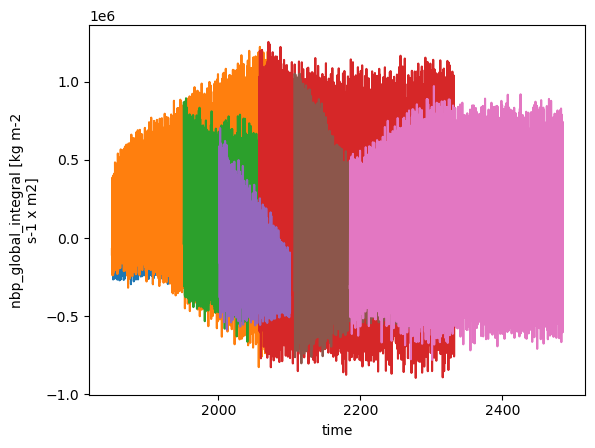

In [5]:
for key in global_stats.keys():
    print(f'... plotting {key} ...')
    global_stats[key].plot()
plt.show()